In [1]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2025_[NeuRIPS_L2S_P]_Synthetic_image_generation_for_deep_coded_wavefront_sensing/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

import torch
from torch import nn, Tensor
from torchvision.models.optical_flow import raft_large
from torchvision.models.optical_flow import Raft_Large_Weights
import torchvision.transforms.functional as F
from torchvision.utils import flow_to_image
from torch.utils.tensorboard import SummaryWriter

from scipy.ndimage import gaussian_filter, median_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator
import scipy

import numpy as np
import matplotlib.pyplot as plt
from zernike import RZern

from typing import Optional, Union

import cws_module

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


# Zernike coeeffs based cell data simulation and maybe inference

In [15]:
def generate_cell(HEK_params, cart, meshgrid, mean_var=5e-4, std_var=5, ran_crop=True, ran_flip=True, ran_rotate=True):
    
    temp_coeffs = std_var*HEK_params[1]*np.random.rand(861) + HEK_params[0] + mean_var*np.random.rand(861)
    gen_cell = np.where(cart.eval_grid(temp_coeffs, matrix=True) < 0.005, 0., cart.eval_grid(temp_coeffs, matrix=True))
    gen_cell = np.where(meshgrid[0]**2 + meshgrid[1]**2 > 0.5, 0., gen_cell)
    
    if ran_crop:
        # random crop -> displace the cell and change the size of the cell
        ch = 50 + np.random.randint(-50, 100)
        cv = -50 + np.random.randint(-100, 50)
        
        gen_cell = gen_cell[ch:cv, ch:cv]
        
        crop_odd = (ch -1*cv) % 2 == 1
        pad_by = np.ceil((ch -1*cv)/2).astype(int)
        if crop_odd:
            gen_cell = gen_cell[:-1, :-1]
            
        gen_cell = np.pad(gen_cell, pad_by)
        
    if ran_flip:
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        gen_cell = np.flip(gen_cell, axis=np.random.randint(0, 2))
        
    if ran_rotate:
        gen_cell = scipy.ndimage.rotate(gen_cell, np.random.randint(-45, 45), reshape=False)
    
    return gen_cell


def create_phase_mask(height_range, grid_shape, tile_size, wl, RI_pm):
    h_pm = wl/np.random.randint(height_range[0], height_range[1])
    hmap_pm = geometry.initialize_hmap_uniform_sampling(grid_shape[:2], tile_size, h_pm)
    opd_pm = hmap_pm*RI_pm + (hmap_pm.max() - hmap_pm)*1. # phase mask in air
    
    return np.exp(1j*(2*np.pi/wl)*opd_pm)


# model
def init_model_RAFT(model, device='cuda', checkpoint=None):
    
    if checkpoint == None:
        print('Loading models with pretrained weights')
        weights = Raft_Large_Weights.DEFAULT.get_state_dict()
        weights['feature_encoder.convnormrelu.0.weight'] = torch.mean(weights['feature_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
        weights['context_encoder.convnormrelu.0.weight'] = torch.mean(weights['context_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
    else:
        print(f'Loading models with checkpoint: {checkpoint}')
        weights = torch.load(checkpoint, map_location=torch.device(device))
    
    # model = raft_large(progress=False)
    model.feature_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    model.context_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    
    model.load_state_dict(weights)
    
    return model.to(device)
    

def RAFT_loss(predictions, target, device='cuda'):
	loss_fn = torch.nn.L1Loss()
	N = len(predictions)
	
	w = torch.pow(torch.tensor(0.8), N-torch.tensor(range(1, N+1))).to(device)
	loss_n = torch.sum(torch.abs(torch.stack(predictions, dim=0) - target.unsqueeze(0).repeat(12, 1, 1, 1, 1)), dim=[1, 2, 3, 4])
	
	return torch.sum(w*loss_n).squeeze()


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

In [113]:
def generate_ref_obj_wavefields(RI_distribution, phase_mask, dist_m_im, dist_m_im_var,
                                wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1):

    k = 2*np.pi/wl
    output_field = propagator.propagate_beam_2(np.ones_like(RI_distribution[..., 1]), RI_distribution, n_background, wl, spatial_resolution)
    
    # prop to focal plane
    output_field = propagator.propagate(output_field, wl/n_background, spatial_resolution, spatial_support[2]/2, padding=padding, direction='backward')

    # NA based low-pass filtering
    # output_field = utils.low_pass_filter_NA(output_field, wl, spatial_resolution, NA)
    
    # prop back to mask plane from image plane (plus variation) ensures focus plane imaging
    output_field = propagator.propagate(output_field, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='backward')
    # output_field = gaussian_filter(output_field, np.random.rand() + 8.) # smoothing -> partial spatial coherence
    
    # ground truth flow
    flow_y, flow_x = utils.grad_optr(np.angle(output_field))
    # gt_flow_y = (np.remainder(flow_y + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[0]*mag)**2/k*(dist_m_im + dist_m_im_var)
    # gt_flow_x = (np.remainder(flow_x + np.pi, 2*np.pi) - np.pi)/(spatial_resolution[1]*mag)**2/k*(dist_m_im + dist_m_im_var)
    gt_flow_y = median_filter(flow_y, 7)/(spatial_resolution[0]*mag)**2/k*(dist_m_im + dist_m_im_var)
    gt_flow_x = median_filter(flow_x, 7)/(spatial_resolution[1]*mag)**2/k*(dist_m_im + dist_m_im_var)
    
    # mask modulation and prop to image plane
    output_field = propagator.propagate(output_field*phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    ref_field = propagator.propagate(phase_mask, wl, np.array(spatial_resolution)*mag, dist_m_im + dist_m_im_var, 
                                        padding=padding, direction='forward')
    
    return ref_field[5:-5, 5:-5], output_field[5:-5, 5:-5], [-1*gt_flow_x[5:-5, 5:-5], -1*gt_flow_y[5:-5, 5:-5]]


def create_phase_mask(height_range, grid_shape, tile_size, wl, RI_pm):
    h_pm = wl/np.random.randint(height_range[0], height_range[1])
    hmap_pm = geometry.initialize_hmap_uniform_sampling(grid_shape[:2], tile_size, h_pm)
    opd_pm = hmap_pm*RI_pm + (hmap_pm.max() - hmap_pm)*1. # phase mask in air
    
    return np.exp(1j*(2*np.pi/wl)*opd_pm)


# model
def init_model_RAFT(model, device='cuda', checkpoint=None):
    
    if checkpoint == None:
        print('Loading models with pretrained weights')
        weights = Raft_Large_Weights.DEFAULT.get_state_dict()
        weights['feature_encoder.convnormrelu.0.weight'] = torch.mean(weights['feature_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
        weights['context_encoder.convnormrelu.0.weight'] = torch.mean(weights['context_encoder.convnormrelu.0.weight'], dim=1).unsqueeze(1)
    else:
        print(f'Loading models with checkpoint: {checkpoint}')
        weights = torch.load(checkpoint, map_location=torch.device(device))
    
    # model = raft_large(progress=False)
    model.feature_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    model.context_encoder.convnormrelu[0] = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    
    model.load_state_dict(weights)
    
    return model.to(device)
    

def RAFT_loss(predictions, target, device='cuda'):
	loss_fn = torch.nn.L1Loss()
	N = len(predictions)
	
	w = torch.pow(torch.tensor(0.8), N-torch.tensor(range(1, N+1))).to(device)
	loss_n = torch.sum(torch.abs(torch.stack(predictions, dim=0) - target.unsqueeze(0).repeat(12, 1, 1, 1, 1)), dim=[1, 2, 3, 4])
	
	return torch.sum(w*loss_n).squeeze()


def plot(imgs, **imshow_kwargs):
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]

    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

    plt.tight_layout()

## DHM cell data - Zerniike Fit -> v9-4

## Generate Synthetic Cell
1. Remove background by thresholding
2. Random cropping and displacement

In [16]:
cart = RZern(40)
L, K = 700, 700
ddx = np.linspace(-1.0, 1.0, K)
ddy = np.linspace(-1.0, 1.0, L)
xv, yv = np.meshgrid(ddx, ddy)
cart.make_cart_grid(xv, yv)

KeyboardInterrupt: 

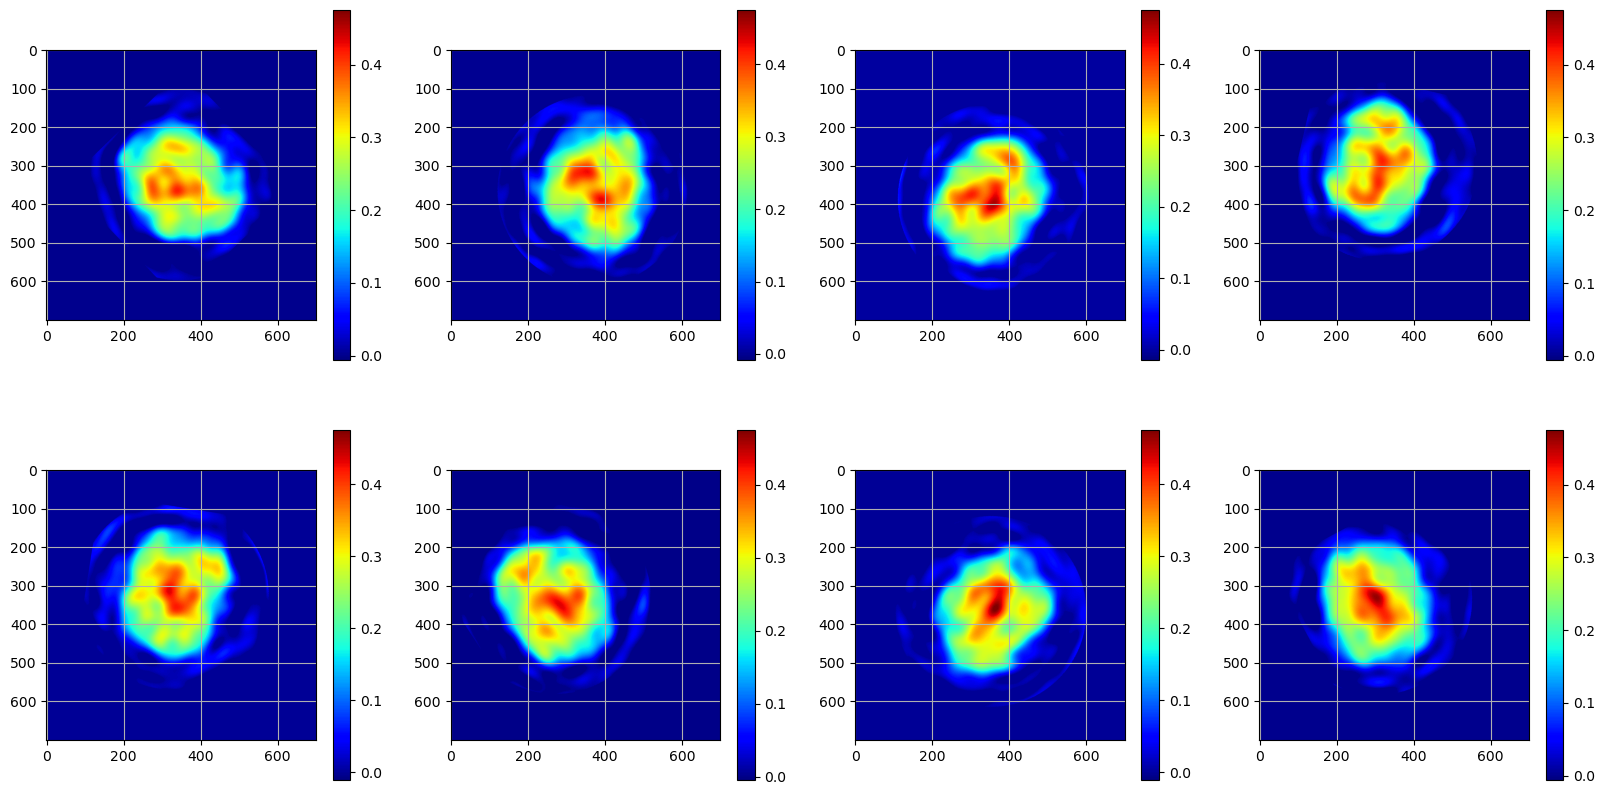

In [ ]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# HEK cell generator parameters
HEK_mean = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['mean'].ravel()
HEK_std = scipy.io.loadmat(f'HEK_synth_data_generstor.mat')['std'].ravel()

for i in range(8):
    
    temp = generate_cell([HEK_mean, HEK_std], cart, [xv, yv], mean_var=5e-4, std_var=8, ran_crop=True, ran_flip=True, ran_rotate=True)
    cm = axs[int(i>3), i%4].imshow(temp, cmap='jet', vmax=0.475)
    plt.colorbar(cm, ax=axs[int(i>3), i%4])
    axs[int(i>3), i%4].grid()
    
plt.show()

In [ ]:
# inference on simulated data



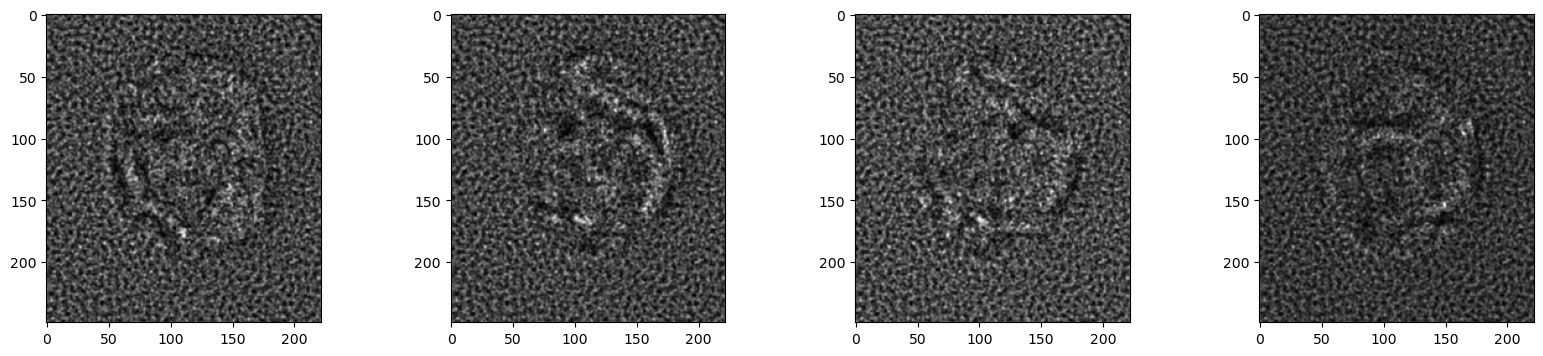

In [ ]:
# validation cell video

cell_ref = tifffile.imread('data/cell_video/measurement/ref_cell_4.tif')[100:-135, 50:-50]
cell_obj_arr = tifffile.imread('data/cell_video/measurement/cell_4_0.tif')[::100, 100:-135, 50:-50]
# [::100, 75:-110, 25:-25]
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

axs[0].imshow(cell_obj_arr[0]/cell_obj_arr[0].max(), cmap='gray')
axs[1].imshow(cell_obj_arr[1]/cell_obj_arr[1].max(), cmap='gray')
axs[2].imshow(cell_obj_arr[2]/cell_obj_arr[2].max(), cmap='gray')
axs[3].imshow(cell_obj_arr[3]/cell_obj_arr[3].max(), cmap='gray')

plt.show()

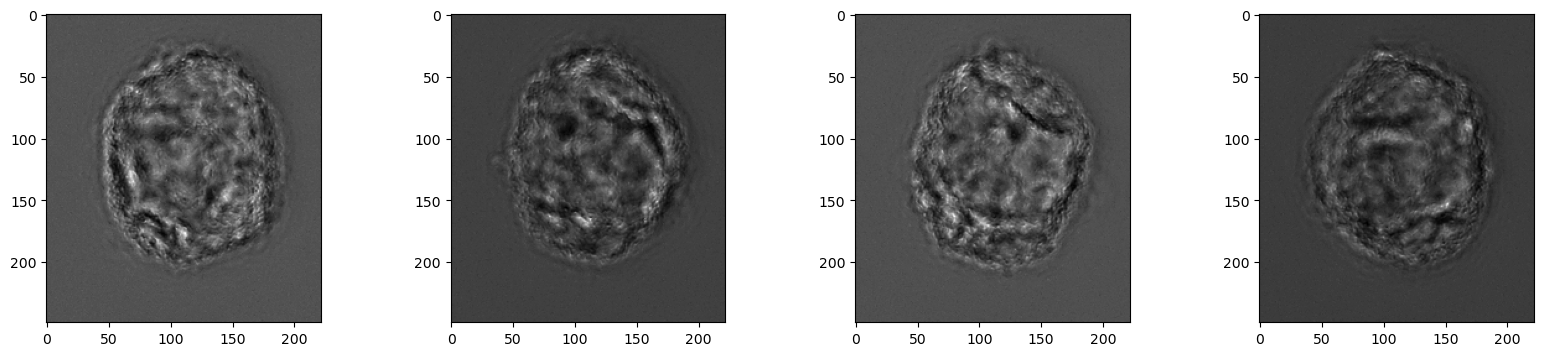

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(20, 4))

amp_cell_0 = cell_obj_arr[0]/cell_ref
amp_cell_1 = cell_obj_arr[1]/cell_ref
amp_cell_2 = cell_obj_arr[2]/cell_ref
amp_cell_3 = cell_obj_arr[3]/cell_ref

axs[0].imshow(amp_cell_0, cmap='gray')
axs[1].imshow(amp_cell_1, cmap='gray')
axs[2].imshow(amp_cell_2, cmap='gray')
axs[3].imshow(amp_cell_3, cmap='gray')

plt.show()

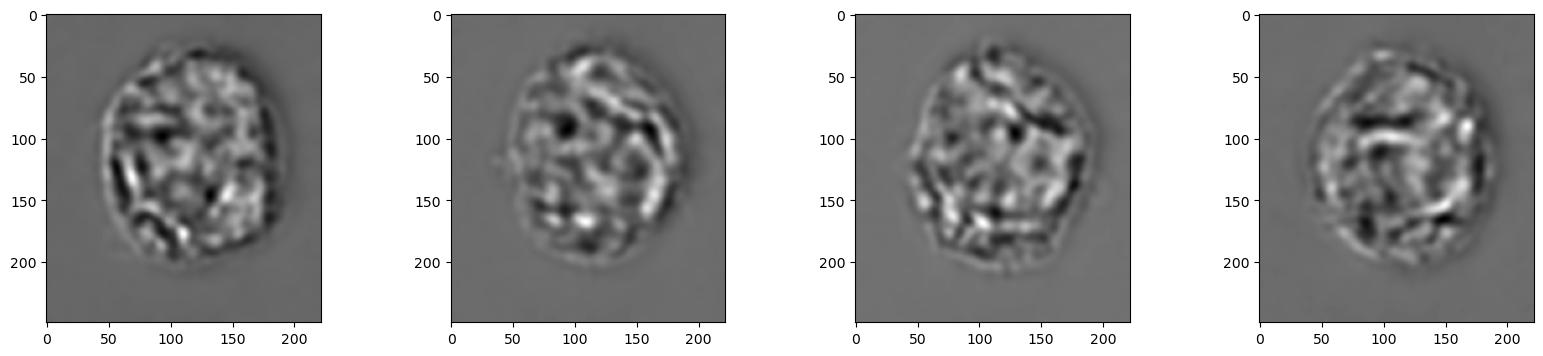

In [ ]:
cell_ref_lpf = gaussian_filter(cell_ref, 3)
cell_0_lpf = gaussian_filter(cell_obj_arr[0], 3)
cell_1_lpf = gaussian_filter(cell_obj_arr[1], 3)
cell_2_lpf = gaussian_filter(cell_obj_arr[2], 3)
cell_3_lpf = gaussian_filter(cell_obj_arr[3], 3)

fig, axs = plt.subplots(1, 4, figsize=(20, 4))

axs[0].imshow(cell_0_lpf/cell_ref_lpf, cmap='gray')
axs[1].imshow(cell_1_lpf/cell_ref_lpf, cmap='gray')
axs[2].imshow(cell_2_lpf/cell_ref_lpf, cmap='gray')
axs[3].imshow(cell_3_lpf/cell_ref_lpf, cmap='gray')

plt.show()

Updating weights


/tmp/ipykernel_313851/4054493493.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))


iter = 0, obj = 2.2102e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.252e-01
iter = 1, obj = 1.6250e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.881e-01
iter = 2, obj = 1.3909e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.437e-01
iter = 3, obj = 1.2167e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.107e-01
iter = 4, obj = 1.0863e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.822e-01
iter = 5, obj = 9.8633e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.589e-01
iter = 6, obj = 9.1223e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.562e-01
iter = 7, obj = 8.4600e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.357e-01
iter = 8, obj = 8.0003e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.136e-01
iter = 9, obj = 7.6328e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.025e-01
iter = 10, obj = 7.3391e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.304e-02
iter = 11, obj = 7.0828e+08
-- A-update
--

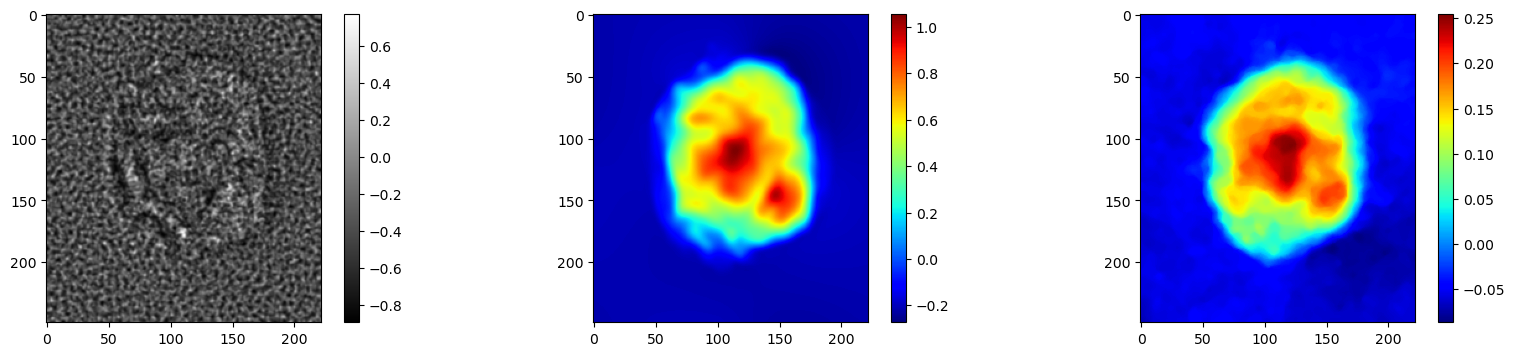

iter = 0, obj = 2.6344e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.494e-01
iter = 1, obj = 1.6536e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.104e-01
iter = 2, obj = 1.4099e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.685e-01
iter = 3, obj = 1.2240e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.273e-01
iter = 4, obj = 1.0867e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.994e-01
iter = 5, obj = 9.8075e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.808e-01
iter = 6, obj = 8.9672e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.565e-01
iter = 7, obj = 8.3173e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.355e-01
iter = 8, obj = 7.8278e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.185e-01
iter = 9, obj = 7.4525e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.097e-01
iter = 10, obj = 7.1499e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.490e-02
iter = 11, obj = 6.9107e+08
-- A-update
--

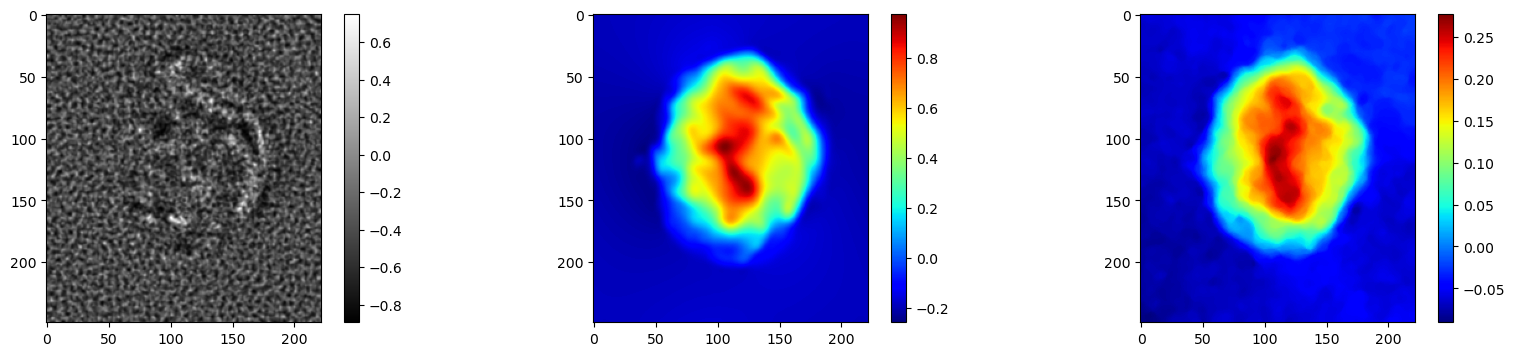

iter = 0, obj = 2.3016e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.214e-01
iter = 1, obj = 1.7077e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.755e-01
iter = 2, obj = 1.4676e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.572e-01
iter = 3, obj = 1.2829e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.223e-01
iter = 4, obj = 1.1393e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.014e-01
iter = 5, obj = 1.0324e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.746e-01
iter = 6, obj = 9.4990e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.527e-01
iter = 7, obj = 8.8731e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.407e-01
iter = 8, obj = 8.3673e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.210e-01
iter = 9, obj = 7.9728e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.182e-01
iter = 10, obj = 7.6569e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.030e-01
iter = 11, obj = 7.3758e+08
-- A-update
--

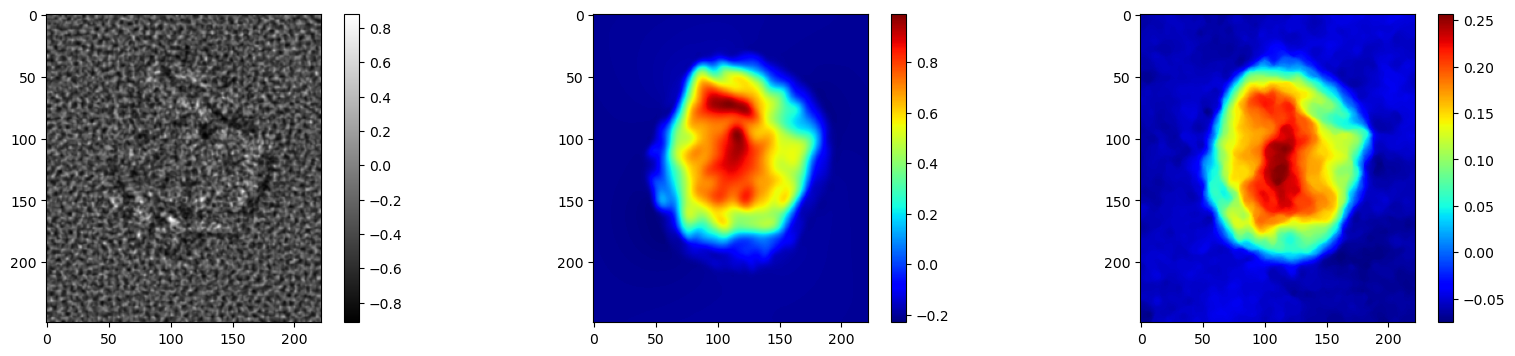

iter = 0, obj = 2.2169e+10
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.422e-01
iter = 1, obj = 1.5267e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 3.056e-01
iter = 2, obj = 1.3054e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.645e-01
iter = 3, obj = 1.1345e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.286e-01
iter = 4, obj = 1.0064e+09
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 2.026e-01
iter = 5, obj = 9.1157e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.741e-01
iter = 6, obj = 8.3958e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.547e-01
iter = 7, obj = 7.8289e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.376e-01
iter = 8, obj = 7.3958e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.201e-01
iter = 9, obj = 7.0608e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 1.088e-01
iter = 10, obj = 6.7814e+08
-- A-update
-- phi-update
-- mean(|\Delta\phi|) = 9.310e-02
iter = 11, obj = 6.5836e+08
-- A-update
--

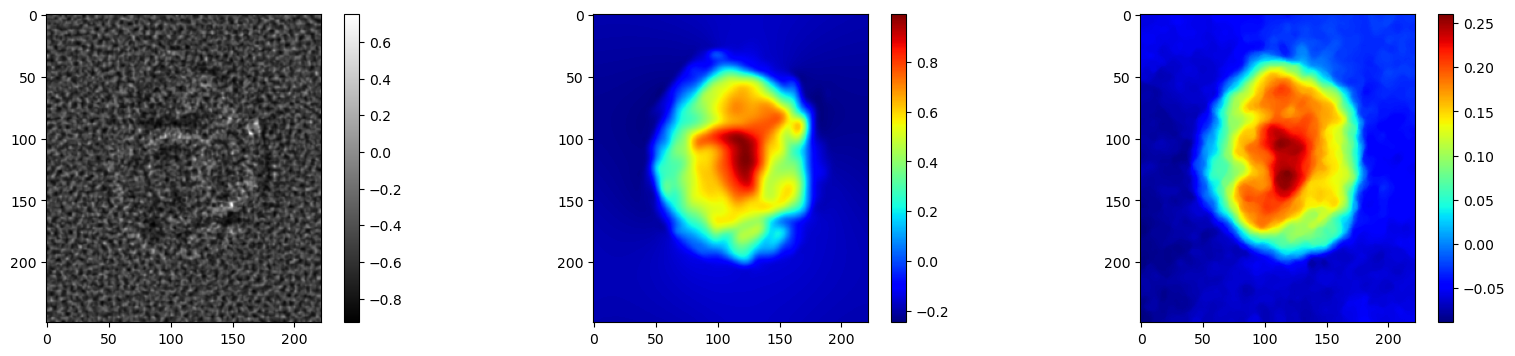

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

ckpt_num = 1400 # 1490

# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v1_blur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v2_blur_RAFT_l_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-04/ckpt/RAFT_synthetic_beads_v3_blur_RAFT_medianFTarget_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-05/ckpt/RAFT_synthetic_beads_v4_hblur_RAFT_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v5_Hblur_RAFT_hnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v6_Hblur_RAFT_nnoise_rcrop_rfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v7_Hblur_RAFT_nnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v8_Hblur_RAFT_lnoise_rcrop_rlfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-09/ckpt/RAFT_synthetic_beads_v9_hblurField_RAFT_lnoise_rcrop_rlfocus_30Packed_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-14/ckpt/RAFT_synthetic_beads_v10_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-21/ckpt/RAFT_synthetic_cells_v11_blur_RAFT_lnoise_rcrop_rnfocus_l1_{ckpt_num}.pth'
# ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v12_blur_RAFT_lnoise_conv3_l1_{ckpt_num}.pth'
ckpt = f'runs/2025-07-22/ckpt/RAFT_synthetic_cells_v13_blur_RAFT_lnoise_conv3_gt_l1_{ckpt_num}.pth'

transforms = utils.OpticalFlowTransformRAFT()

if 'model' in locals():
    print('Updating weights')
    model.load_state_dict(torch.load(ckpt, map_location=torch.device(device)))
else:
    model = init_model_RAFT(raft_large(progress=False), device=device, checkpoint=ckpt)

wc_reconstructor = cws_module.CWS()
# prior = [0.001, 40, 0.01, 0.005]
prior = [100, 1000, 100, 5]
iter = [15, 5, 5]

im_ref_cell = torch.tensor(cell_ref).float()
model.eval()
with torch.no_grad():
    for i in range(4):
        cell_ref_val = []
        cell_obj_val = []
        
        im_obj_cell = torch.tensor(cell_obj_arr[i]).float()
        
        cell_ref_val.append(im_ref_cell/im_ref_cell.max())
        cell_obj_val.append(im_obj_cell/im_obj_cell.max())
        
        img1_batch_val_cell, img2_batch_val_cell = utils.preprocess(cell_ref_val, cell_obj_val, transforms)
        
        list_of_flows_val = model(img1_batch_val_cell.to(device), img2_batch_val_cell.to(device))
        predicted_flows_val = F.resize(list_of_flows_val[-1].detach().cpu(), size=(cell_ref.shape))
        
        _, _, _ = wc_reconstructor.run(im_ref_cell.detach().numpy().astype(np.float64), 
                        im_obj_cell.detach().numpy().astype(np.float64), 
                        prior=prior, iter=iter)
        _, opd = wc_reconstructor.get_field(pixel_size=6.45e-6, z=1.43e-3, RI=2.)
        
        fx, axs = plt.subplots(1, 3, figsize=(20, 4), sharex=True)

        im1 = axs[0].imshow(F.resize(img2_batch_val_cell.detach(), size=(cell_ref.shape))[0, 0], cmap='gray')
        plt.colorbar(im1, ax=axs[0])
        im2 = axs[1].imshow(1e6*utils.int_2d_fourier([predicted_flows_val[0, 0], predicted_flows_val[0, 1]], (6.45e-6)**2/1.43e-3), cmap='jet', 
                            # vmax=0.65, vmin=-0.05
                            )
        plt.colorbar(im2, ax=axs[1])
        
        im3 = axs[2].imshow(median_filter(opd*1e6, 7), cmap='jet')
        plt.colorbar(im3, ax=axs[2])
        
        plt.show()

In [223]:

losses = []
epochs = 1
update_wegiths_iter = 1

# Grid and propagation parameters setup
wl = 640e-9
spatial_resolution = [200e-9, 200e-9, 200e-9] # dx, dy, dz
grid_shape = [500, 500, 200] # x=0->, y=0->, z=0->
n_background = 1.382 # immersion medium RI
spatial_support = [spatial_resolution[i]*grid_shape[i] for i in range(3)]

c_m = [50e-6, 50e-6, 20e-6]
c_v = [15e-6, 15e-6, 3e-9]
rad_params = [5, 10, 1e-6]
RI_params = [1.37, 0.001]

dist_m_im = 2e-3 # meters
pad = 512
mag = 10

side_length = 10e-6
tile_size = int(side_length/(spatial_resolution[0]*mag))
RI_pm = 1.46
# h_pm = wl/(2*(RI_pm - 1.))

int_gaus_noise = 1e-1

geom = geometry.Geometry(grid_shape, spatial_resolution, n_background)
transforms = utils.OpticalFlowTransformRAFT()

Coordiante system with size: 
 
              X = [0, 1.00e-04], Res_X = 2e-07
              Y = [0, 1.00e-04], Res_Y = 2e-07
              Z = [0, 4.00e-05], Res_Z = 2e-07
              Immersion RI: 1.382
      


In [234]:
for it1 in range(epochs):
    
    # generate phase mask
    phase_mask = create_phase_mask([1000, 1001], grid_shape, tile_size, wl, RI_pm)
    
    ref_imgs = []
    obj_imgs = []
    gt_flows = []
    
    model.train()
    for it2 in range(update_wegiths_iter):
        
        # generate data 3D tensor
        num_elements = np.random.randint(10, 11)
        print(f'{it1}:{it2}-{num_elements}')
        
        
        RI_distribution_1 = geometry.generate_bead_data(geom, c_m, c_v, rad_params, RI_params, num_elements).get_grid()
        geom.reset_grid() # sets back to background RI. Initialization not required again.
        
        # generate NN input and label
        dist_m_im_var = np.random.randn()*1e-3*0
        ref_wave, obj_wave, gt_flow = generate_ref_obj_wavefields(RI_distribution_1, phase_mask, dist_m_im, dist_m_im_var,
                                    wl, n_background, spatial_resolution, spatial_support, mag, padding=256, NA=1)
        
        img_ref = torch.clamp(torch.abs(torch.tensor(ref_wave))**2 + 0*int_gaus_noise*torch.randn(490, 490), min=0).float()
        img_obj = torch.clamp(torch.abs(torch.tensor(obj_wave))**2 + 0*int_gaus_noise*torch.randn(490, 490), min=0).float()
        
        ref_imgs.append(img_ref/img_ref.max()) # model expects a list of tensors. Converts to [min, 1.]
        obj_imgs.append(img_obj/img_obj.max())
        gt_flows.append(gt_flow) # ground truth flow

0:0-10


In [269]:
visualization.visualize_grid_vol(RI_distribution_1, n_background=n_background, factor=1)

Text(0.5, 1.0, 'Object Wave Phase at Sensor')

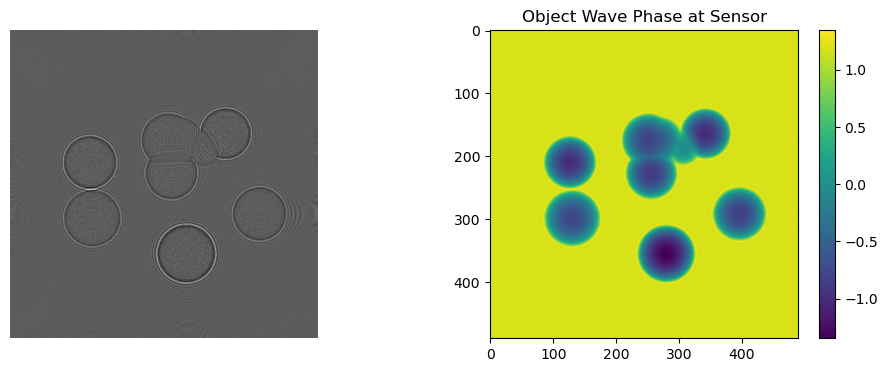

In [258]:
fx, axs = plt.subplots(1, 2, figsize=(12, 4))

# im1 = axs[0].imshow(np.abs(propagator.propagate(obj_wave, wl, [spatial_resolution[0]*mag,spatial_resolution[1]*mag],
                                                # 5e-4, 512))**2, cmap='gray')
im1 = axs[0].imshow(img_obj/img_ref, cmap='gray')
# plt.colorbar(im1, ax=axs[0])
# axs[0].set_title('Object Wave Amplitude at Sensor')
axs[0].set_axis_off()

im2 = axs[1].imshow(np.angle(obj_wave))
plt.colorbar(im2, ax=axs[1])
axs[1].set_title('Object Wave Phase at Sensor')

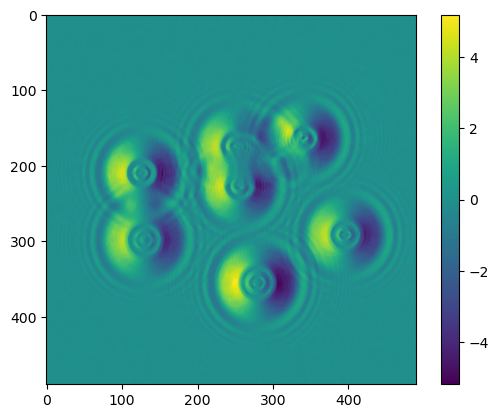

In [236]:
plt.imshow(gt_flows[0][0])
plt.colorbar()

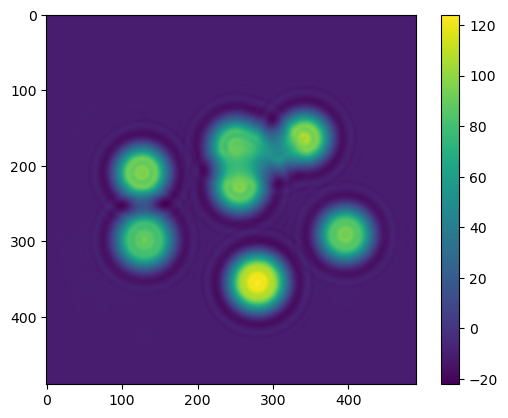

In [237]:
est_phase = utils.int_2d_fourier(gt_flows[0], 1)
plt.imshow(est_phase)
plt.colorbar()

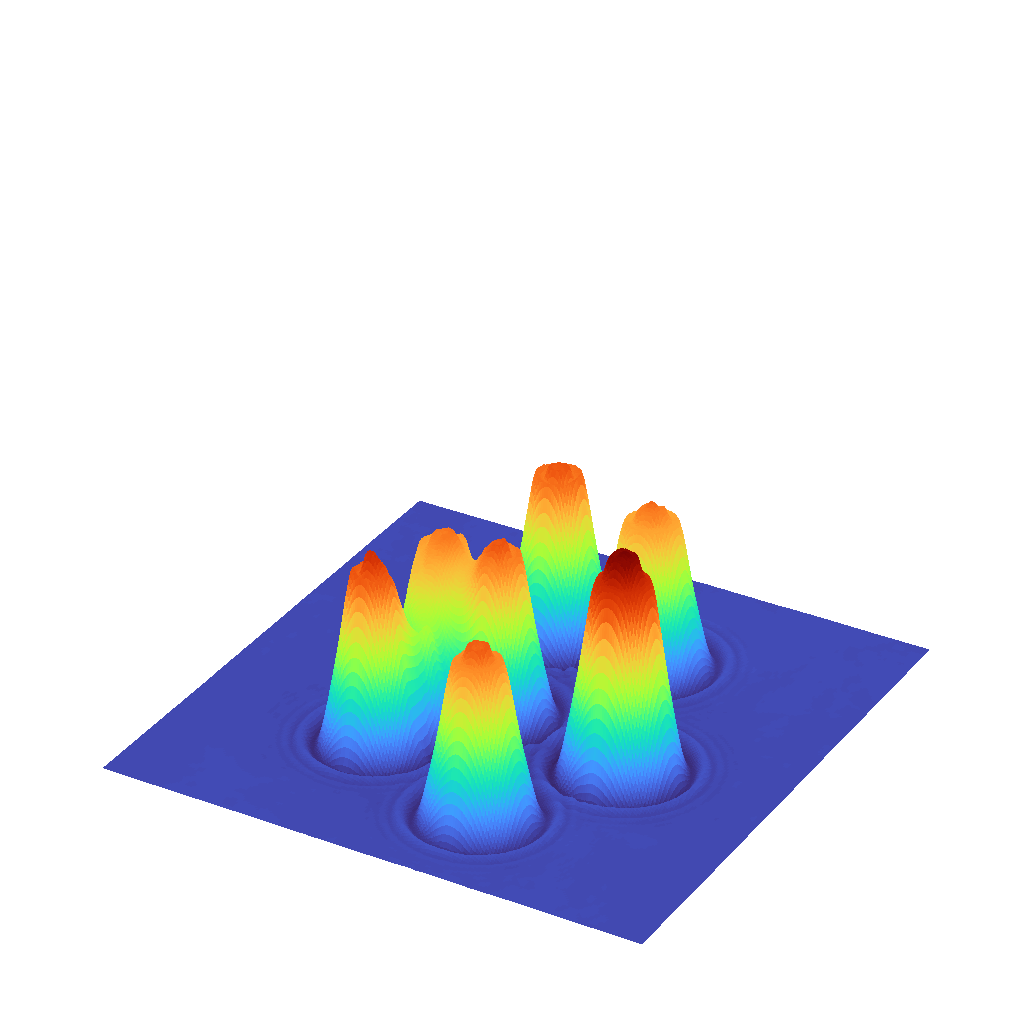

In [263]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})

# Make data.
X = np.linspace(-5, 5, 490)
Y = np.linspace(-5, 5, 490)
X, Y = np.meshgrid(X, Y)

# Plot the surface.
surf = ax.plot_surface(X, Y, est_phase, cmap=cm.turbo,
                       linewidth=0, antialiased=False, rcount=300, ccount=300)

# Customize the z axis.
ax.set_zlim(0, 250)
ax.zaxis.set_major_locator(LinearLocator(100))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
# fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_axis_off()
ax.view_init(azim=30, elev=30)
# plt.tight_layout()
plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, 
            hspace = 0, wspace = 0)
plt.margins(0,0,0)
plt.savefig("opd_example.png", bbox_inches = 'tight',
    pad_inches = 0)
plt.show()

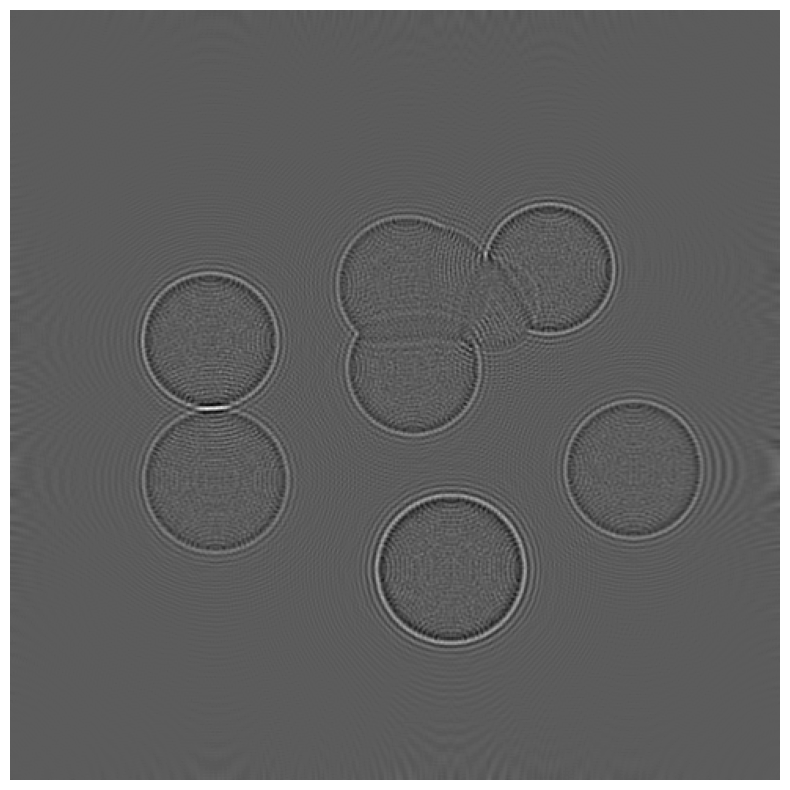

In [262]:
fx, axs = plt.subplots(figsize=(10, 10))

# im1 = axs[0].imshow(np.abs(propagator.propagate(obj_wave, wl, [spatial_resolution[0]*mag,spatial_resolution[1]*mag],
                                                # 5e-4, 512))**2, cmap='gray')
im1 = axs.imshow(img_obj/img_ref, cmap='gray')
# plt.colorbar(im1, ax=axs[0])
# axs[0].set_title('Object Wave Amplitude at Sensor')
axs.set_axis_off()
plt.savefig("amp_example.png", bbox_inches = 'tight',
    pad_inches = 0)
plt.show()

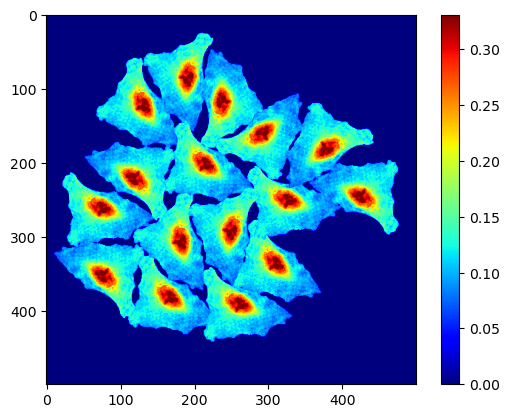

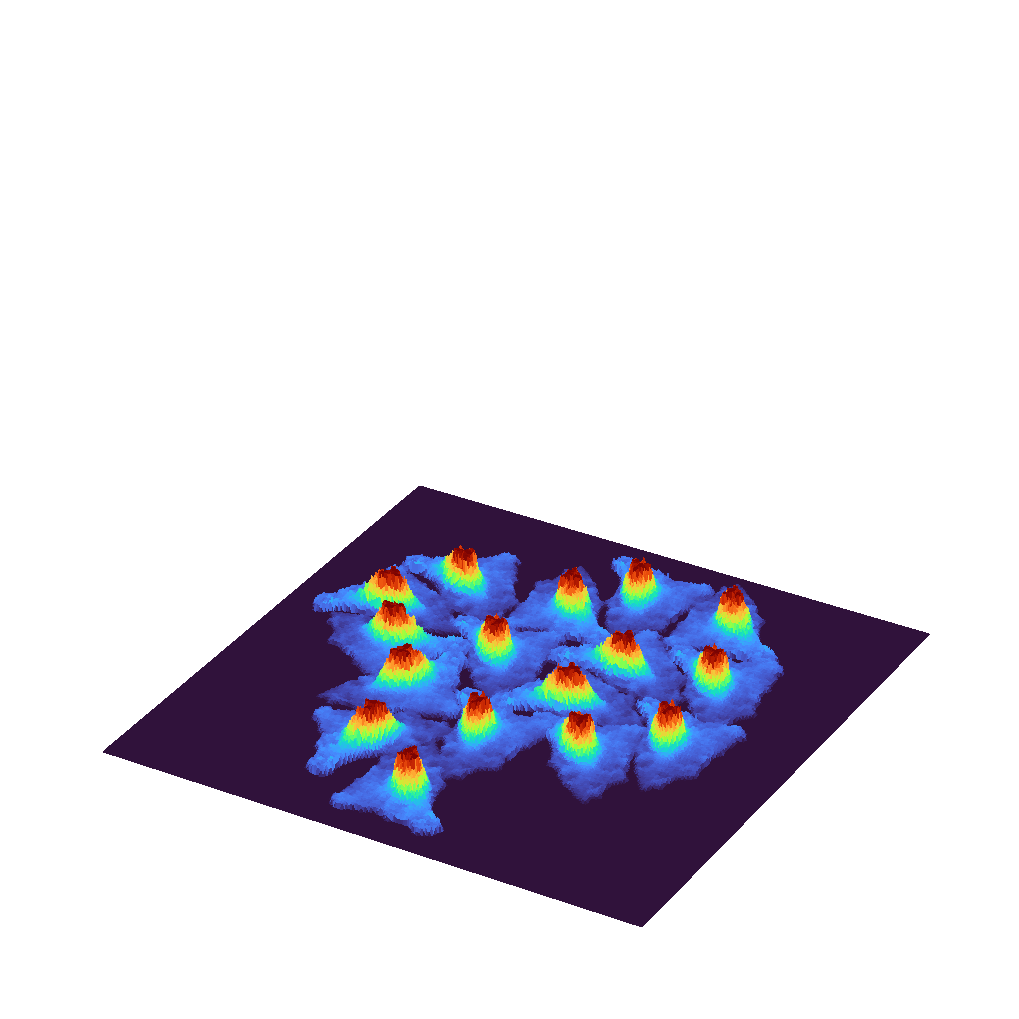

In [19]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

path_dir = '/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/Data/Printed_Phantom/phase_maps'
import scipy

k = 2*np.pi/633e-9

cell_cluster = (scipy.io.loadmat(f'{path_dir}/05_confluence_4.mat')['phase_map']/(k*(1.55-1.5123))*(1.55-1.512)*1e6)[230:2730:5, 230:2730:5]

plt.imshow(cell_cluster, cmap='jet')
plt.colorbar()
plt.show()

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": "3d"})

# Make data.
X = np.linspace(-5, 5, 500)
Y = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(X, Y)

# Plot the surface.
surf = ax.plot_surface(X, Y, (15*cell_cluster)**2, cmap=cm.turbo,
                       linewidth=0, antialiased=False, rcount=300, ccount=300)

# Customize the z axis.
ax.set_zlim(0, 250)
ax.zaxis.set_major_locator(LinearLocator(100))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
# fig.colorbar(surf, shrink=0.5, aspect=5)
ax.set_axis_off()
ax.view_init(azim=30, elev=30)
# plt.tight_layout()
plt.subplots_adjust(top = 1, bottom = 0, right = 1, left = 0, 
            hspace = 0, wspace = 0)
plt.margins(0,0,0)
plt.savefig("opd_example.png", bbox_inches = 'tight',
    pad_inches = 0)
plt.show()